# **Tugas 3 - Logistic Regression**

**Nama : Achmad Baharuddin Akbar**

**NIM  : 210411100001**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPW-A/report/tugas-ppw/hasil_preprocesing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,Jakarta Sifilis atau penyakit raja singa term...,jakarta sifilis atau penyakit raja singa term...,"['jakarta', 'sifilis', 'atau', 'penyakit', 'ra...",jakarta sifilis penyakit raja singa infeksi me...
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,Jakarta Sebagian orang pasti sudah mengenal i...,jakarta sebagian orang pasti sudah mengenal i...,"['jakarta', 'sebagian', 'orang', 'pasti', 'sud...",jakarta orang mengenal istilah puncak seksual ...
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,Jakarta Setiap orang mungkin pernah mengalami...,jakarta setiap orang mungkin pernah mengalami...,"['jakarta', 'setiap', 'orang', 'mungkin', 'per...",jakarta orang mengalami sariawan luka mulut me...
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,Jakarta Air rebusan serai dikenal sebagai sal...,jakarta air rebusan serai dikenal sebagai sal...,"['jakarta', 'air', 'rebusan', 'serai', 'dikena...",jakarta air rebusan serai dikenal salah ramuan...
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,Jakarta Viral momen member NewJeans Hanni ber...,jakarta viral momen member newjeans hanni ber...,"['jakarta', 'viral', 'momen', 'member', 'newje...",jakarta viral momen member newjeans hanni berb...


## **Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Transformasi data kategorik
label_encoder = LabelEncoder()
df.loc[:, 'kategori_encoded'] = label_encoder.fit_transform(df['kategori'])

# Menampilkan nilai sebelum dan sesudah konversi
print("\nNilai sebelum dan sesudah konversi:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

print("\nDataFrame setelah Label Encoding:")
df


Nilai sebelum dan sesudah konversi:
{'Kesehatan': 0, 'Kuliner': 1}

DataFrame setelah Label Encoding:


,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,Filtering/stopword removal,kategori_encoded
0,Gejala Sifilis pada Wanita Berdasarkan Tahapan...,"Rabu, 16 Okt 2024 21:00 WIB",Jakarta - Sifilis atau penyakit raja singa ter...,Kesehatan,Jakarta Sifilis atau penyakit raja singa term...,jakarta sifilis atau penyakit raja singa term...,"['jakarta', 'sifilis', 'atau', 'penyakit', 'ra...",jakarta sifilis penyakit raja singa infeksi me...,0
1,Puncak Nafsu Pria Ada di Umur Berapa? Studi Bi...,"Rabu, 16 Okt 2024 20:02 WIB",Jakarta - Sebagian orang pasti sudah mengenal ...,Kesehatan,Jakarta Sebagian orang pasti sudah mengenal i...,jakarta sebagian orang pasti sudah mengenal i...,"['jakarta', 'sebagian', 'orang', 'pasti', 'sud...",jakarta orang mengenal istilah puncak seksual ...,0
2,"Gejala Kanker Mulut yang Kerap Tak Disadari, T...","Rabu, 16 Okt 2024 18:02 WIB",Jakarta - Setiap orang mungkin pernah mengalam...,Kesehatan,Jakarta Setiap orang mungkin pernah mengalami...,jakarta setiap orang mungkin pernah mengalami...,"['jakarta', 'setiap', 'orang', 'mungkin', 'per...",jakarta orang mengalami sariawan luka mulut me...,0
3,Kapan Waktu yang Tepat untuk Minum Air Rebusan...,"Rabu, 16 Okt 2024 17:31 WIB",Jakarta - Air rebusan serai dikenal sebagai sa...,Kesehatan,Jakarta Air rebusan serai dikenal sebagai sal...,jakarta air rebusan serai dikenal sebagai sal...,"['jakarta', 'air', 'rebusan', 'serai', 'dikena...",jakarta air rebusan serai dikenal salah ramuan...,0
4,Viral Hanni NewJeans Bicara soal Bullying di T...,"Rabu, 16 Okt 2024 16:34 WIB","Jakarta - Viral momen member NewJeans, Hanni, ...",Kesehatan,Jakarta Viral momen member NewJeans Hanni ber...,jakarta viral momen member newjeans hanni ber...,"['jakarta', 'viral', 'momen', 'member', 'newje...",jakarta viral momen member newjeans hanni berb...,0
...,...,...,...,...,...,...,...,...,...
95,Lamaknyo! Soto Padang Isian Daging Goreng Ada ...,"Selasa, 15 Okt 2024 12:00 WIB",Jakarta - Tak kalah populer dengan jenis soto ...,Kuliner,Jakarta Tak kalah populer dengan jenis soto l...,jakarta tak kalah populer dengan jenis soto l...,"['jakarta', 'tak', 'kalah', 'populer', 'dengan...",jakarta kalah populer jenis soto soto padang k...,1
96,Duh! Kedai Lumpia Ini Ditutup 14 Hari Usai Tem...,"Selasa, 15 Okt 2024 11:30 WIB",Jakarta - Kedai yang terkenal dengan hidangan ...,Kuliner,Jakarta Kedai yang terkenal dengan hidangan l...,jakarta kedai yang terkenal dengan hidangan l...,"['jakarta', 'kedai', 'yang', 'terkenal', 'deng...",jakarta kedai terkenal hidangan lumpia terpaks...,1
97,"Resep Cempedak Goreng Krispi, Manis Renyah Unt...","Selasa, 15 Okt 2024 11:00 WIB",Tentang Bahan Langkah Jakarta - Cempedak yang ...,Kuliner,Tentang Bahan Langkah Jakarta Cempedak yang m...,tentang bahan langkah jakarta cempedak yang m...,"['tentang', 'bahan', 'langkah', 'jakarta', 'ce...",bahan langkah jakarta cempedak manis legit har...,1
98,10 Tampilan Makanan yang Disebut Buruk Rupa Ta...,"Selasa, 15 Okt 2024 10:30 WIB",Jakarta - Meski tampilan beberapa makanan ini ...,Kuliner,Jakarta Meski tampilan beberapa makanan ini d...,jakarta meski tampilan beberapa makanan ini d...,"['jakarta', 'meski', 'tampilan', 'beberapa', '...",jakarta tampilan makanan dianggap buruk rupa a...,1


## **Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

# Split data
x = df ['Filtering/stopword removal']
y = df ['kategori_encoded']

print(x)
print(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

print("="*50)
print("Jumlah data latih:", len(x_train))
print("Jumlah data uji:", len(x_test))



0     jakarta sifilis penyakit raja singa infeksi me...
1     jakarta orang mengenal istilah puncak seksual ...
2     jakarta orang mengalami sariawan luka mulut me...
3     jakarta air rebusan serai dikenal salah ramuan...
4     jakarta viral momen member newjeans hanni berb...
                            ...                        
95    jakarta kalah populer jenis soto soto padang k...
96    jakarta kedai terkenal hidangan lumpia terpaks...
97    bahan langkah jakarta cempedak manis legit har...
98    jakarta tampilan makanan dianggap buruk rupa a...
99    bahan langkah jakarta bosan tumisan ayam coba ...
Name: Filtering/stopword removal, Length: 100, dtype: object
0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: kategori_encoded, Length: 100, dtype: int64
Jumlah data latih: 80
Jumlah data uji: 20


## **TF-IDF (Term Frequency-Inverse Document Frequency)**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Menggunakan kolom 'cleaned_text' sebagai teks input dan 'kategori' sebagai label
texts = df['Filtering/stopword removal'].fillna('')  # Mengganti NaN dengan string kosong jika ada
labels = df['kategori'].fillna('unknown')  # Mengganti NaN di kategori jika ada

# Melihat label yang digunakan untuk klasifikasi
print(labels.unique())

['Kesehatan' 'Kuliner']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Fit dan transform pada data training
x_train_tfidf = tfidf.fit_transform(x_train)

# Transform pada data testing
x_test_tfidf = tfidf.transform(x_test)

# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(x_train_tfidf.toarray(), columns=feature_names)

# Konversi TF-IDF hasil testing ke DataFrame
df_test_tfidf = pd.DataFrame(x_test_tfidf.toarray(), columns=feature_names)

# Tampilkan hasil TF-IDF dalam DataFrame
print("TF-IDF untuk data training:")
print(df_train_tfidf)

print("\nTF-IDF untuk data testing:")
print(df_test_tfidf)

TF-IDF untuk data training:
    abai  abc   abdalla  abdullah  abis      acar  acara  aceh  activation  \
0    0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
1    0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
2    0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
3    0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
4    0.0  0.0  0.000000       0.0   0.0  0.055323    0.0   0.0         0.0   
..   ...  ...       ...       ...   ...       ...    ...   ...         ...   
75   0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
76   0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
77   0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   
78   0.0  0.0  0.034643       0.0   0.0  0.000000    0.0   0.0         0.0   
79   0.0  0.0  0.000000       0.0   0.0  0.000000    0.0   0.0         0.0   

    acuannya  ...  yorkpresbyterian

In [ ]:
from sklearn.linear_model import LogisticRegression

# Latih model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## **Evaluasi Model**



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.70      1.00      0.82         7

    accuracy                           0.85        20
   macro avg       0.85      0.88      0.85        20
weighted avg       0.89      0.85      0.85        20



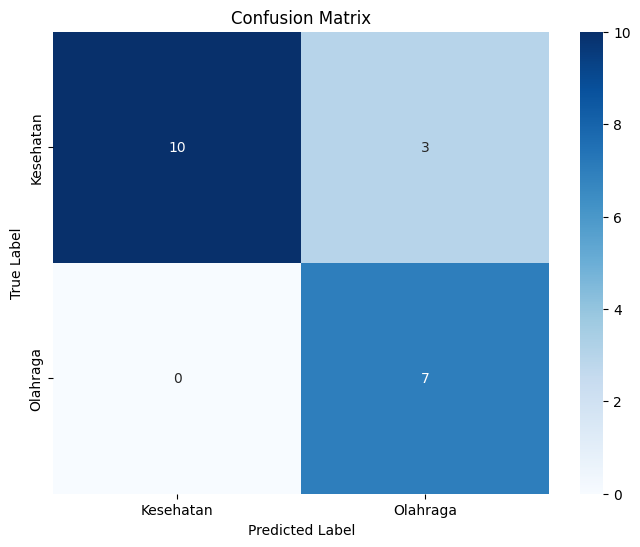

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi
y_pred = logistic_model.predict(x_test_tfidf)

# Tampilkan classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Buat confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Definisikan label untuk confusion matrix
labels = ['Kesehatan', 'Olahraga']

# Buat heatmap confusion matrix menggunakan seaborn dengan label yang diinginkan
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pickle
import joblib

# Save the TfidfVectorizer instead of x_train_tfidf
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

# Save the trained Logistic Regression model
with open('logistic_model.pkl', 'wb') as file:
    pickle.dump(logistic_model, file)

print("TfidfVectorizer and Logistic Regression model have been successfully saved.")

# Menyimpan model TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf_model.joblib')

# Menyimpan model Logistic Regression
joblib.dump(logistic_model, 'logistic_regression_model.joblib')

print("Model Logistic Regression dan TF-IDF telah disimpan dengan joblib.")

TfidfVectorizer and Logistic Regression model have been successfully saved.
Model Logistic Regression dan TF-IDF telah disimpan dengan joblib.


## **Pengujian**

In [ ]:
import joblib

# Teks baru yang ingin diprediksi
new_text_1 = ['''
Jakarta - Badan Pengawas Obat dan Makanan (BPOM) belum lama ini menyita 10 jenis obat herbal ilegal yang dijual bebas di daerah Jawa Barat. Obat herbal ini diketahui mengandung bahan kimia obat (BKO) yang dapat memicu penyakit gagal ginjal dan jantung. Berikut adalah daftar produk yang disita BPOM dan berpotensi bisa merusak jantung serta ginjal: Cobra X, Spider, Africa Black Ant, Cobra India, Tawon Liar, Wan Tong, Kapsul Asam Urat TCU, Antanan, Tongkat Arab, Xian Liang. Obat ini terbilang berbahaya karena dapat merusak ginjal hingga jantung karena mengandung BKO seperti sildenafil, fenilbutazon, metampiron, piroksikam, parasetamol, hingga deksametason. Ketua Perkumpulan Dokter Pengembang Obat Tradisional Jamu Indonesia (PDPOTJI) dr Inggrid Tania mengatakan masalah kesehatan seperti gagal ginjal hingga penyakit jantung memang bisa saja terjadi pada seseorang yang mengonsumsi obat herbal ilegal tersebut. "Obat herbal yang mengandung BKO ini memang bisa mencetuskan penyakit gagal ginjal hingga gagal liver. Ini karena produsennya itu menambahkan BKO tapi tidak ditulis dalam kemasan, dengan kadar yang kita tidak ketahui. Bisa saja kadarnya banyak, melebihi batas aman," ujar dr Inggrid saat dihubungi detikcom, Kamis (10/10/2024). Tujuan para produsen, lanjut dr Inggrid memberikan BKO melebihi batas adalah untuk mendukung produk mereka yang memiliki klaim 'bombastis' seperti dapat meredakan nyeri dengan cepat atau efektif mengatasi kesulitan ereksi pada pria. Sebetulnya, obat-obat herbal berbahaya ini memiliki ciri khas tersendiri, sehingga bisa dijadikan perhatian oleh masyarakat. Menurut dr Anggi, biasanya obat herbal ilegal ini memiliki klaim bombastis pada produknya serta tidak memiliki nomor izin edar Badan POM. "Kalau dari kajian kami, literasi masyarakat kita soal obat herbal masih rendah ya. Kebanyakan mereka tidak tahu izin edar obat herbal itu tidak ada atau bodong," katanya. "Apalagi ketika mereka mencoba obatnya untuk pertama kali dan merasakan efek 'cespleng' karena kan obatnya dicampur dengan bahan kimia dengan takaran yang besar sebetulnya. Mereka merasa obatnya manjur, jadinya beli lagi dan konsumsi lagi," tutupnya. (dpy/naf)
''']

new_text_2 = ['''
Jakarta - Aktif di YouTuber dan TikTok, food vlogger ini memberi pandangannya soal etika saat mengulas makanan. Jangan sampai, ulasannya bisa menjatuhkan usaha orang lain. Di zaman digitalnya ini muncul insan-insan kreatif, seperti food vlogger dan semacamnya. Kehadiran food vlogger agaknya memberikan dampak tersendiri bagi pelaku usaha kuliner, ada negatif dan juga positif. Positifnya bisa membantu mempromosikan usaha milik orang lain. Namun, sebaliknya, food vlogger terkadang bisa mematikan usaha karena hasil ulasannya yang terkesan menjatuhkan. Seperti yang belum lama ini terjadi, seorang food vlogger sampai di-blacklist oleh pengusaha kuliner di Yogyakarta setelah memberi komentar menjatuhkan pada warung makan rawon. Food Vlogger Perlu Tahu! Begini Etika Mengulas Makanan Foto: iStock Dari kejadian tersebut, banyak pelaku usaha kuliner terutama Usaha Mikro, Kecil, dan Menengah (UMKM) yang khawatir dengan kehadiran para food vlogger. Food vlogger yang eksis bernama Almas pun memberikan pandangannya. Melalui TikTok @almasqol (03/10/24) ia mengatakan bahwa seharusnya ada etiket tersendiri saat mengulas makanan. Apalagi ketika food vlogger datang tanpa undangan atau seperti pelanggan biasa. "Kita sebagai konten kreator makanan itu seharusnya lebih mendukung UMKM supaya makanan atau produknya itu lebih dikenal, gimana caranya agar UMKM tetap naik," ujarnya dalam video yang dikonfirmasi detikFood (16/10/24). Food vlogger dengan 1,7 juta followers itu mengakui bahwa dirinya sebagai konten kreator makanan tidak begitu memahami detail rasa dan istilah dalam kuliner. Food Vlogger ilustrasi. Foto: iStock Namun, meski begitu, ia dapat menyampaikan informasi penting mengenai makanan yang dicicipinya. "Mengulas makanan ya udah sewajarnya, kasih info-info penting dan keseluruhan rasa," tuturnya. Menurutnya, jika rasanya kurang memuaskan bisa menyampaikan keluhan langsung ke pemilik usaha. Namun, jika rasanya enak bisa langsung sampaikan ke khalayak ramai lewat video kreatif. "Karena kalau menjatuhkan itu gak cuma ownernya aja, di situ ada karyawan yang dihidupkan dan dari makan di tempat itu," tutur food vlogger yang terkenal dengan jargon 'wenak cik!'. Dengan kasus tersebut, menjadi pembelajaran bagi ia dan konten kreator lain. Ia juga berharap agar semua konten kreator dapat lebih bijak dalam bersosial media. Videonya pun ramai ditanggapi netizen. Banyak netizen yang sependapat dengan pandangan Almas mengenai fenomena food vlogger. "Setuju, seharusnya kritik bisa disampaikan dengan etika yang baik dan harus membangun. Jangan cuma komentar jelek gak berguna," tulis netizen. "Orang tua gue jualan makanan kaki lima, jujur gue khawatir banget kalau ada food vlogger yang gak beretika kayak gitu, gak kebayang gimana sedihnya orang tua," tuturnya. @almasqol Ber Oponi !! #wenakcik #almasqol ♬ Monkeys Spinning Monkeys - dg cria (raf/odi)
''']

# Load the saved vectorizer and model
tfidf = joblib.load('tfidf_model.joblib')
model = joblib.load('logistic_regression_model.joblib')

# New texts to predict
new_text = new_text_1 + new_text_2

# Preprocess and transform using the loaded TF-IDF vectorizer
new_text_tfidf = tfidf.transform(new_text)

# Predict using the Logistic Regression model
predictions = model.predict(new_text_tfidf)

# Map predictions to categories
predicted_categories = ["Kesehatan" if prediction == 0 else "Kuliner" for prediction in predictions]

# Output the predictions
for i, category in enumerate(predicted_categories):
    print(f"Prediction for text {i+1}: {category}")


Prediction for text 1: Kesehatan
Prediction for text 2: Kuliner
